In [1]:
import pandas as pd 

df_ML = pd.read_csv("ML_data.csv")


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,ConfusionMatrixDisplay, roc_auc_score

from xgboost import XGBClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

FileNotFoundError: [Errno 2] No such file or directory: 'ML_data.csv'

In [ ]:
df_ML

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0,1,0,0
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,1,0,0
9997,709,0,36,7,0.00,1,0,1,42085.58,1,1,0,0
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,0,1,0


**************************** ML_RandomForestClassifier **********************************

In [ ]:
X = df_ML.drop(columns=["Exited"]) # variable explicatives
Y = df_ML["Exited"] # Cible

In [ ]:

X_train, X_test, Y_train, Y_test = train_test_split(X, Y ,test_size= 0.2,random_state= 42)

RFC = RandomForestClassifier( 
    n_estimators=400,
    max_depth=10,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42
) 

RFC.fit(X_train,Y_train)
y_proba = RFC.predict_proba(X_test)[:,1]
y_pred = (y_proba > 0.3).astype(int)

accuracy = accuracy_score(Y_test, y_pred)
print(accuracy)

confusion_m = confusion_matrix(Y_test,y_pred)
print(confusion_m)

classif_report = classification_report(Y_test, y_pred)
classif_report

0.682
[[1019  588]
 [  48  345]]


'              precision    recall  f1-score   support\n\n           0       0.96      0.63      0.76      1607\n           1       0.37      0.88      0.52       393\n\n    accuracy                           0.68      2000\n   macro avg       0.66      0.76      0.64      2000\nweighted avg       0.84      0.68      0.71      2000\n'

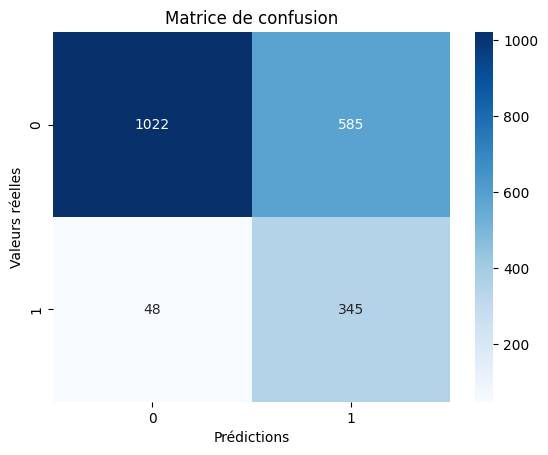

In [ ]:
# Matrice de confusion pour RandomForestClassifier 
cm = confusion_m
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.show()

******************************** ML _ XGBClassifier ******************************************

In [ ]:


X1_train, X1_test, Y1_train, Y1_test = train_test_split(X, Y ,test_size= 0.2,random_state= 42,stratify=Y)


scale_pos_weight = len(Y1_train[Y1_train==0]) / len(Y1_train[Y1_train==1])

# Création du modèle XGBoost
XGB = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

# Entraînement
XGB.fit(X1_train, Y1_train)

# Prédictions avec seuil par défaut (0.5)
y1_pred = XGB.predict(X1_test)


accuracy1 = accuracy_score(Y1_test, y1_pred)
print(accuracy1)

confusion_m1 = confusion_matrix(Y1_test,y1_pred)
print(confusion_m1)

classif_report1 = classification_report(Y1_test, y1_pred)
classif_report1

0.826
[[1391  202]
 [ 146  261]]


'              precision    recall  f1-score   support\n\n           0       0.91      0.87      0.89      1593\n           1       0.56      0.64      0.60       407\n\n    accuracy                           0.83      2000\n   macro avg       0.73      0.76      0.74      2000\nweighted avg       0.84      0.83      0.83      2000\n'

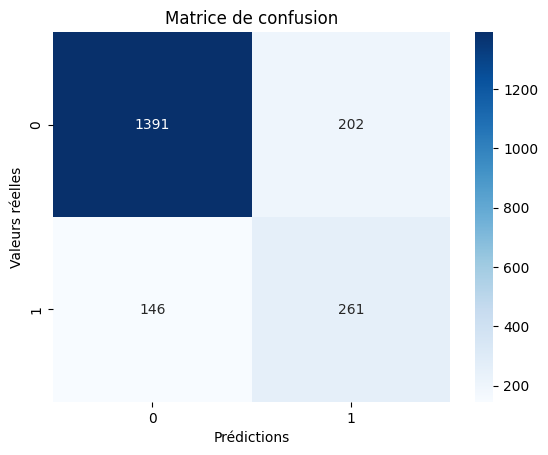

In [ ]:
# Matrice de confusion pour XGBOOST 
cm1 = confusion_m1
sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.show()

************************* ML_LogisticRegression *****************************************

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1593
           1       0.42      0.64      0.51       407

    accuracy                           0.75      2000
   macro avg       0.66      0.71      0.67      2000
weighted avg       0.80      0.75      0.77      2000



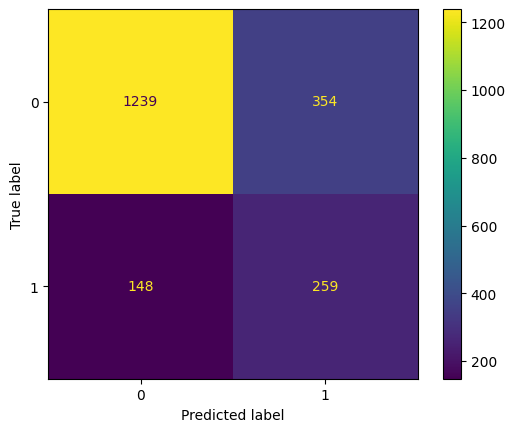

In [ ]:
# Separation des données en entrenement et test
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y  # Split avec stratification (important en dataset déséquilibré)
)

# Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X3_train)
X_test_scaled = scaler.transform(X3_test)

# Modèle
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # ajuste automatiquement le déséquilibre
    solver='liblinear'
)

# Entraînement correct
model.fit(X_train_scaled, y3_train)

# Probabilités
y_proba = model.predict_proba(X_test_scaled)[:, 1] 

# Ajustement du seuil (tu peux tester 0.4 / 0.45 / 0.5 / 0.55)
threshold = 0.55
y_pred = (y_proba > threshold).astype(int)

# Évaluation
print("Classification Report")
print(classification_report(y3_test, y_pred))


# Matrice de confusion
cm3 = confusion_matrix(y3_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=[0, 1])
disp.plot()
plt.show()

Conclusion

***Random Forest***   est le meilleur modèle globalement :

Meilleure accuracy  Random Forest :

Meilleur F1-score pour les deux classes Random Forest :

**  Meilleure détection de la classe minoritaire  

Moins de faux négatifs pour la classe 1

XGBoost est un très bon deuxième choix, tandis que la régression logistique est clairement moins performante pour la classe minoritaire.


********************** Pipline RandomForestClassifier *******************************

In [ ]:
from sklearn.pipeline import Pipeline

# Split des données
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Création du pipeline
pipeline = Pipeline([
    ('rfc', RandomForestClassifier(
        n_estimators=400,
        max_depth=10,
        min_samples_leaf=4,
        class_weight="balanced",
        random_state=42
    ))
])

# Entraînement du pipeline
pipeline.fit(X_train, Y_train)

# Prédictions probabilistes
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Application du seuil 0.3 pour obtenir les classes
y_pred = (y_proba > 0.3).astype(int)

# Évaluation
accuracy = accuracy_score(Y_test, y_pred)
print("Accuracy :", accuracy)

confusion_m = confusion_matrix(Y_test, y_pred)
print("Confusion Matrix :\n", confusion_m)

classif_report = classification_report(Y_test, y_pred)
print("Classification Report :\n", classif_report)

Accuracy : 0.682
Confusion Matrix :
 [[1019  588]
 [  48  345]]
Classification Report :
               precision    recall  f1-score   support

           0       0.96      0.63      0.76      1607
           1       0.37      0.88      0.52       393

    accuracy                           0.68      2000
   macro avg       0.66      0.76      0.64      2000
weighted avg       0.84      0.68      0.71      2000



In [ ]:
import os
print("Dossier courant :", os.getcwd())

Dossier courant : c:\Users\adnan\Documents\Projet_Bank_Churn\model


In [ ]:

import pickle

path = r"C:\Users\adnan\Documents\Projet_Bank_Churn\model\pipeline_churn.pkl"

with open(path, "wb") as f:
    pickle.dump(pipeline, f)

print("Pipeline sauvegardé à :", path)

Pipeline sauvegardé à : C:\Users\adnan\Documents\Projet_Bank_Churn\model\pipeline_churn.pkl
